In [1]:
# # Install dependencies
# !pip install tabpfn autogluon catboost lightgbm xgboost pandas numpy matplotlib seaborn
# !git clone https://github.com/PriorLabs/tabpfn-extensions
# !pip install -e tabpfn-extensions[all]
# !pip install scikit-learn==1.5.2
# !pip install "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"

In [2]:
from IPython.display import display, HTML
from tqdm.notebook import tqdm
import subprocess

# --- Phase 1: Lightweight packages ---
phase1 = [
    "scikit-learn==1.5.2",
    "tabpfn",
    "catboost",
    "xgboost",
    "lightgbm",
    "datasets",
    "ucimlrepo",
    "ace_tools"
]

# --- Phase 2: Heavy or Git-based packages ---
phase2 = [
    "autogluon==0.8.2 --no-cache-dir --upgrade",
    "tabpfn-extensions[all] @ git+https://github.com/PriorLabs/tabpfn-extensions.git"
]

# --- Function to install packages with live output ---
def install_packages(package_list, phase_name):
    logs = []
    display(HTML(f"<h3>🚀 Starting {phase_name}</h3>"))
    for pkg in tqdm(package_list, desc=f"{phase_name}", unit="pkg"):
        display(HTML(f"<b>Installing:</b> {pkg}"))
        process = subprocess.Popen(
            ["pip", "install", "--no-cache-dir", "--upgrade", pkg],
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True
        )
        output = ""
        for line in process.stdout:
            output += line
        process.wait()
        logs.append(f"📦 {pkg}\n{output}")
    return logs

# --- Run both phases ---
logs_phase1 = install_packages(phase1, "Phase 1: Core Packages")
logs_phase2 = install_packages(phase2, "Phase 2: Heavy/Git Packages")

# --- Display combined logs ---
all_logs = logs_phase1 + logs_phase2
scrollable_logs = (
    "<pre style='max-height: 400px; overflow-y: scroll; border: 1px solid #ccc; padding: 10px;'>"
    + "\n\n".join(all_logs) + "</pre>"
)
display(HTML(scrollable_logs))

Phase 1: Core Packages:   0%|          | 0/8 [00:00<?, ?pkg/s]

Phase 2: Heavy/Git Packages:   0%|          | 0/2 [00:00<?, ?pkg/s]

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas_profiling import ProfileReport
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import catboost as cb
import lightgbm as lgb
import xgboost as xgb
# ---- Unified benchmarking (integrated; with fitted_models) ----
import time
from autogluon.tabular import TabularPredictor
import catboost as cb, lightgbm as lgb, xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Optional imports with fallbacks
# AutoGluon
try:
    from autogluon.tabular import TabularPredictor
    AGLUON_AVAILABLE = True
except ImportError as e:
    print("Warning: AutoGluon import failed:", e)
    AGLUON_AVAILABLE = False

# TabPFN
from tabpfn import TabPFNClassifier
# try:
#   from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier, AutoTabPFNRegressor
# except:
#   raise SystemError('Please restart the session to fix this import.')
from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier

/tmp/ipykernel_36/659467975.py:5: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


In [4]:
# 3) Load dataset (update the file path as needed)
# heart-disease-dataset = '/kaggle/input/heart-disease-dataset'
# df = pd.read_csv(heart-disease-dataset)

# ada_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/ada_dataset.csv'
# df = pd.read_csv(ada_dataset)

australian_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/australian_dataset.csv'
df = pd.read_csv(australian_dataset)

# blood_transfusion-service-center_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/blood_transfusion-service-center.csv'
# df = pd.read_csv(blood_transfusion-service-center_dataset)

# car_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/car.csv'
# df = pd.read_csv(car_dataset)

# chum_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/chum.csv'
# df = pd.read_csv(chum_dataset)

# cmc_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/cmc.csv'
# df = pd.read_csv(cmc_dataset)

# credit-g_dataset = '/kaggle/input/seven-datasets-for-classification-test-on-tabpfn/Classification DataSets/credit-g.csv'
# df = pd.read_csv(credit-g_dataset)

In [5]:
# 4) Dataset overview and information
print("Shape of the dataset:", df.shape)
df.info()
print("\nFirst few rows:")
display(df.head())
print("\nLast few rows:")
display(df.tail())
print("\nDescriptive statistics:")
display(df.describe(include='all').T)
print("\nMissing values per column:")
display(df.isnull().sum().sort_values(ascending=False))
print("\nMemory usage per column:")
display(df.memory_usage(deep=True))
print("\nUnique value counts per column:")
display(df.nunique())
print("\nData types of each column:")
display(df.dtypes)

Shape of the dataset: (690, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   A1      690 non-null    int64
 1   A2      690 non-null    int64
 2   A3      690 non-null    int64
 3   A4      690 non-null    int64
 4   A5      690 non-null    int64
 5   A6      690 non-null    int64
 6   A7      690 non-null    int64
 7   A8      690 non-null    int64
 8   A9      690 non-null    int64
 9   A10     690 non-null    int64
 10  A11     690 non-null    int64
 11  A12     690 non-null    int64
 12  A13     690 non-null    int64
 13  A14     690 non-null    int64
 14  target  690 non-null    int64
dtypes: int64(15)
memory usage: 81.0 KB

First few rows:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,target
0,1,65,168,2,4,4,39,0,0,1,1,2,32,161,0
1,0,72,123,2,8,4,5,0,0,1,0,2,53,1,0
2,0,142,52,1,4,4,31,0,0,1,1,2,98,1,0
3,0,60,169,1,5,3,1,1,1,12,1,2,1,1,1
4,1,44,134,2,6,4,46,1,1,15,0,2,18,68,1



Last few rows:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,target
685,1,163,160,2,14,4,99,1,0,1,0,2,1,1,1
686,1,49,14,2,8,4,4,0,0,1,0,2,1,35,0
687,0,32,145,2,6,4,3,1,0,1,0,2,32,1,1
688,0,122,193,2,14,8,67,1,1,2,0,2,38,12,1
689,1,245,2,2,10,4,2,0,1,2,0,1,159,1,1



Descriptive statistics:


...

Index      132
A1        5520
A2        5520
A3        5520
A4        5520
A5        5520
A6        5520
A7        5520
A8        5520
A9        5520
A10       5520
A11       5520
A12       5520
A13       5520
A14       5520
target    5520
dtype: int64


Unique value counts per column:


A1          2
A2        350
A3        215
A4          3
A5         14
A6          8
A7        132
A8          2
A9          2
A10        23
A11         2
A12         3
A13       171
A14       240
target      2
dtype: int64


Data types of each column:


A1        int64
A2        int64
A3        int64
A4        int64
A5        int64
A6        int64
A7        int64
A8        int64
A9        int64
A10       int64
A11       int64
A12       int64
A13       int64
A14       int64
target    int64
dtype: object

In [6]:
# # 6) Generate an interactive profiling report (optional)
# profile = ProfileReport(df, title="Profiling Report", explorative=True)
# profile.to_notebook_iframe()

### 5. Separate target and features

In [7]:
# Keep target vector separate from X
target = 'target'
if target not in df.columns:
    raise KeyError(f"Target column '{target}' not found in dataframe.")
y = df[target]
X = df.drop(columns=target)

## **5. Data processing**

In [8]:
# 6.1) Identify numerical and categorical columns in X
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 6.2) Handle missing values
num_imputer = SimpleImputer(strategy='median')
X[num_cols] = num_imputer.fit_transform(X[num_cols])
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# 6.3) One-hot encode for processed dataset
if cat_cols:
    X_processed = pd.get_dummies(X, columns=cat_cols, drop_first=True)
else:
    X_processed = X.copy()

# 6.4) Z-normalization on processed numeric features
scaled_cols = [col for col in num_cols if col in X_processed.columns]
X_processed[scaled_cols] = X_processed[scaled_cols].apply(lambda col: (col - col.mean()) / col.std())

# 6.5) Raw encoded features (no scaling)
if cat_cols:
    X_raw = pd.get_dummies(X, columns=cat_cols, drop_first=True)
else:
    X_raw = X.copy()

In [9]:
# 6.4) Z-normalization on processed numeric features
scaled_cols = [col for col in num_cols if col in X_processed.columns]
X_processed[scaled_cols] = X_processed[scaled_cols].apply(lambda col: (col - col.mean()) / col.std())

In [10]:
# 6.5) Raw encoded features (no scaling)
if cat_cols:
    X_raw = pd.get_dummies(X, columns=cat_cols, drop_first=True)
else:
    X_raw = X.copy()

In [11]:
# 7) Train-test split on processed and raw data
processed_X_train, processed_X_test, processed_y_train, processed_y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)
print("Processed train/test shapes:", processed_X_train.shape, processed_X_test.shape)

raw_X_train, raw_X_test, raw_y_train, raw_y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)
print("Raw encoded train/test shapes:", raw_X_train.shape, raw_X_test.shape)

Processed train/test shapes: (552, 14) (138, 14)
Raw encoded train/test shapes: (552, 14) (138, 14)


In [12]:
raw_X_train.head(5)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
278,1.0,177.0,66.0,2.0,13.0,8.0,63.0,1.0,1.0,7.0,0.0,2.0,53.0,183.0
110,1.0,222.0,154.0,1.0,4.0,4.0,4.0,0.0,0.0,1.0,0.0,2.0,53.0,1.0
82,0.0,29.0,151.0,2.0,2.0,4.0,11.0,0.0,0.0,1.0,0.0,2.0,24.0,34.0
51,1.0,53.0,90.0,1.0,3.0,8.0,2.0,0.0,0.0,1.0,0.0,2.0,45.0,50.0
218,1.0,38.0,11.0,2.0,4.0,4.0,8.0,0.0,0.0,1.0,0.0,2.0,98.0,103.0


In [13]:
processed_X_train.head(5)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
278,0.688238,0.304664,-0.283753,0.542556,1.527866,1.660001,0.711616,0.953958,1.156306,0.917469,-0.918529,0.237655,-0.125614,1.758806
110,0.688238,0.788889,1.213033,-1.782685,-0.915618,-0.347713,-0.912439,-1.046745,-0.863570,-0.569736,-0.918529,0.237655,-0.125614,-0.744803
82,-1.450880,-1.287897,1.162006,0.542556,-1.458615,-0.347713,-0.719754,-1.046745,-0.863570,-0.569736,-0.918529,0.237655,-0.753997,-0.290852
51,0.688238,-1.029644,0.124461,-1.782685,-1.187116,1.660001,-0.967491,-1.046745,-0.863570,-0.569736,-0.918529,0.237655,-0.298961,-0.070754
218,0.688238,-1.191053,-1.219245,0.542556,-0.915618,-0.347713,-0.802333,-1.046745,-0.863570,-0.569736,-0.918529,0.237655,0.849463,0.658319


In [14]:
processed_y_train.head(5)

278    1
110    0
82     0
51     0
218    0
Name: target, dtype: int64

In [15]:
raw_y_train.head(20)

278    1
110    0
82     0
51     0
218    0
552    0
446    1
292    1
314    1
534    0
18     0
650    1
487    1
424    0
608    0
61     0
631    0
501    0
29     1
181    0
Name: target, dtype: int64

In [16]:
from tabpfn import TabPFNClassifier


## Benchmark: classification metrics and timing
We evaluate TabPFN, AutoTabPFN, AutoGluon, CatBoost, LightGBM, and XGBoost on **raw** and **processed** datasets.
Metrics reported: **ROC‑AUC, Accuracy, F1 (↑)** and **Cross‑Entropy (CE), ECE (↓)**. Fit time is shown separately.


In [17]:
def to_1d(a):
    if hasattr(a, "values"):
        a = a.values
    a = np.asarray(a)
    return a.ravel()

def prob_pos_from_estimator(estimator, X):
    """Return P(class=1) as 1D numpy array if available; else None."""
    try:
        proba = estimator.predict_proba(X)
    except Exception:
        return None
    if isinstance(proba, pd.DataFrame):
        if 1 in proba.columns:
            return to_1d(proba[1])
        return to_1d(proba.iloc[:, -1])
    if isinstance(proba, pd.Series):
        return to_1d(proba)
    proba = np.asarray(proba)
    if proba.ndim == 2 and proba.shape[1] >= 2:
        return to_1d(proba[:, -1])
    if proba.ndim == 1:
        return to_1d(proba)
    return None

def expected_calibration_error(y_true, y_prob, n_bins=15):
    try:
        y_true = to_1d(y_true).astype(int)
        y_prob = np.clip(to_1d(y_prob).astype(float), 1e-12, 1-1e-12)
    except Exception:
        return np.nan
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    ece = 0.0; n = len(y_true)
    for b in range(n_bins):
        in_bin = bin_ids == b
        m = in_bin.sum()
        if m == 0:
            continue
        acc = (y_true[in_bin] == (y_prob[in_bin] >= 0.5)).mean()
        conf = y_prob[in_bin].mean()
        ece += (m / n) * abs(acc - conf)
    return float(ece)

def safe_log_loss(y_true, y_prob):
    try:
        yp = np.clip(to_1d(y_prob), 1e-12, 1-1e-12)
        y2 = np.column_stack([1 - yp, yp])
        return float(log_loss(to_1d(y_true), y2))
    except Exception:
        try:
            return float(log_loss(to_1d(y_true), to_1d(y_prob)))
        except Exception:
            return np.nan

# Expect these objects to be present from earlier cells:
# processed_X_train, processed_X_test, processed_y_train, processed_y_test
# raw_X_train, raw_X_test, raw_y_train, raw_y_test
datasets = {
    'processed': (processed_X_train, processed_X_test, processed_y_train, processed_y_test),
    'raw': (raw_X_train, raw_X_test, raw_y_train, raw_y_test)
}

results = []
fitted_models = {}  # save trained models: key = (model_name, dataset)

for ds_name, (X_tr, X_te, y_tr, y_te) in datasets.items():
    Xtr_np, Xte_np = getattr(X_tr, "values", X_tr), getattr(X_te, "values", X_te)
    ytr_np, yte_np = to_1d(y_tr), to_1d(y_te)

    # TabPFN (expects numpy)
    try:
        mdl = TabPFNClassifier(random_state=42); t0 = time.time(); mdl.fit(Xtr_np, ytr_np); ft = time.time() - t0
        fitted_models[('TabPFN', ds_name)] = mdl
        y_pred = mdl.predict(Xte_np); y_prob = prob_pos_from_estimator(mdl, Xte_np)
        results.append({'dataset': ds_name, 'model': 'TabPFN', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, y_pred),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, y_pred),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'TabPFN', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # Random Forest
    try:
        mdl = RandomForestClassifier(random_state=42, n_estimators=200)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('RandomForest', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'RandomForest', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'RandomForest', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # Support Vector Machine (needs probability=True)
    try:
        mdl = SVC(probability=True, random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('SVM', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'SVM', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'SVM', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # MLP
    try:
        mdl = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('MLP', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'MLP', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'MLP', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # Logistic Regression
    try:
        mdl = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('LogisticRegression', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'LogisticRegression', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'LogisticRegression', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # AutoTabPFN (expects numpy)
    try:
        mdl = AutoTabPFNClassifier(random_state=42); t0 = time.time(); mdl.fit(Xtr_np, ytr_np); ft = time.time() - t0
        fitted_models[('AutoTabPFN', ds_name)] = mdl
        y_pred = mdl.predict(Xte_np); y_prob = prob_pos_from_estimator(mdl, Xte_np)
        results.append({'dataset': ds_name, 'model': 'AutoTabPFN', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, y_pred),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, y_pred),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'AutoTabPFN', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # AutoGluon (TabularPredictor)
    try:
        label_col = getattr(y_tr, "name", None) or "target"
        ag_train = X_tr.copy(); ag_train[label_col] = y_tr.values if hasattr(y_tr, "values") else y_tr
        t0 = time.time(); predictor = TabularPredictor(label=label_col, eval_metric='accuracy').fit(ag_train, verbosity=0); ft = time.time() - t0
        fitted_models[('AutoGluon', ds_name)] = predictor
        y_pred = predictor.predict(X_te); proba = predictor.predict_proba(X_te)
        if isinstance(proba, pd.DataFrame): y_prob = to_1d(proba.iloc[:, -1])
        elif isinstance(proba, pd.Series): y_prob = to_1d(proba)
        else: y_prob = None
        results.append({'dataset': ds_name, 'model': 'AutoGluon', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'AutoGluon', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # CatBoost
    try:
        mdl = cb.CatBoostClassifier(verbose=0, random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('CatBoost', ds_name)] = mdl
        y_pred = to_1d(mdl.predict(X_te)); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'CatBoost', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, y_pred),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, y_pred),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'CatBoost', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # LightGBM
    try:
        mdl = lgb.LGBMClassifier(random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('LightGBM', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'LightGBM', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'LightGBM', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

    # XGBoost
    try:
        mdl = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
        t0 = time.time(); mdl.fit(X_tr, y_tr); ft = time.time() - t0
        fitted_models[('XGBoost', ds_name)] = mdl
        y_pred = mdl.predict(X_te); y_prob = prob_pos_from_estimator(mdl, X_te)
        results.append({'dataset': ds_name, 'model': 'XGBoost', 'fit_time': ft,
                        'Accuracy': accuracy_score(yte_np, to_1d(y_pred)),
                        'ROC_AUC': roc_auc_score(yte_np, y_prob) if y_prob is not None else np.nan,
                        'F1': f1_score(yte_np, to_1d(y_pred)),
                        'CE': safe_log_loss(yte_np, y_prob) if y_prob is not None else np.nan,
                        'ECE': expected_calibration_error(yte_np, y_prob) if y_prob is not None else np.nan})
    except Exception:
        results.append({'dataset': ds_name, 'model': 'XGBoost', 'fit_time': np.nan,
                        'Accuracy': np.nan, 'ROC_AUC': np.nan, 'F1': np.nan, 'CE': np.nan, 'ECE': np.nan})

results_df = pd.DataFrame(results)
print("Trained models saved in `fitted_models` with keys like ('ModelName', 'processed') and ('ModelName', 'raw').")

tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


tabpfn-v2-classifier-vutqq28w.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

...

tabpfn-v2-classifier-znskzxi4.ckpt:   0%|          | 0.00/12.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

No path specified. Models will be saved in: "AutogluonModels/ag-20250901_140507"
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [14:05:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
No path specified. Models will be saved in: "AutogluonModels/ag-20250901_140814"


Trained models saved in `fitted_models` with keys like ('ModelName', 'processed') and ('ModelName', 'raw').


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [14:08:24] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [18]:
# ## Summary Tables — Raw vs Processed (single CSV)
# Builds separate tables and saves them side-by-side in one CSV.

import numpy as np
import pandas as pd

metrics_up = ['ROC_AUC', 'Accuracy', 'F1']  # higher is better
metrics_down = ['CE', 'ECE']                # lower is better
all_metrics = metrics_up + metrics_down

def make_summary(df_subset):
    """Return summary table for one dataset (raw or processed)."""
    # Best values in this dataset
    bests = {m: df_subset[m].max() for m in metrics_up}
    bests.update({m: df_subset[m].min() for m in metrics_down})

    # Normalized (best = 1.0)
    norm = df_subset[['model']].copy()
    for m in metrics_up:
        norm[m] = df_subset[m] / bests[m]
    for m in metrics_down:
        norm[m] = bests[m] / df_subset[m]
    norm = norm.replace([np.inf, -np.inf], np.nan)

    mean_norm = norm.groupby('model')[all_metrics].mean()
    mean_raw  = df_subset.groupby('model')[all_metrics].mean()

    # Wins (ties allowed)
    wins = pd.DataFrame(0, index=df_subset['model'].unique(), columns=all_metrics, dtype=int)
    for m in metrics_up:
        best_val = df_subset[m].max()
        for mdl in df_subset.loc[np.isclose(df_subset[m], best_val), 'model']:
            wins.loc[mdl, m] += 1
    for m in metrics_down:
        best_val = df_subset[m].min()
        for mdl in df_subset.loc[np.isclose(df_subset[m], best_val), 'model']:
            wins.loc[mdl, m] += 1

    mean_time = df_subset.groupby('model')['fit_time'].mean().rename('Time (s)')

    # Assemble
    left = mean_norm.copy()
    left.columns = pd.MultiIndex.from_product([['Mean Normalized'], left.columns])
    mid  = mean_raw.copy()
    mid.columns  = pd.MultiIndex.from_product([['Mean'], mid.columns])
    win  = wins.copy()
    win.columns  = pd.MultiIndex.from_product([['Wins'], win.columns])
    tm   = mean_time.to_frame()
    tm.columns = pd.MultiIndex.from_product([['Mean'], tm.columns])

    summary = pd.concat([left, mid, win, tm], axis=1)
    summary = summary.reindex(columns=pd.MultiIndex.from_tuples([
        ('Mean Normalized','ROC_AUC'), ('Mean Normalized','Accuracy'), ('Mean Normalized','F1'),
        ('Mean Normalized','CE'), ('Mean Normalized','ECE'),
        ('Mean','ROC_AUC'), ('Mean','Accuracy'), ('Mean','F1'), ('Mean','CE'), ('Mean','ECE'),
        ('Wins','ROC_AUC'), ('Wins','Accuracy'), ('Wins','F1'), ('Wins','CE'), ('Wins','ECE'),
        ('Mean','Time (s)')
    ]))
    return summary

# --- Separate summaries ---
raw_summary  = make_summary(results_df[results_df['dataset'] == 'raw'])
proc_summary = make_summary(results_df[results_df['dataset'] == 'processed'])

# --- (Optional) display nicely in notebook ---
def fmt_summary(dfm, title):
    fmts = {}
    for col in dfm.columns:
        top, sub = col
        if top in ('Mean Normalized','Mean') and sub in all_metrics:
            fmts[col] = "{:.3f}"
        elif top == 'Wins':
            fmts[col] = "{:d}"
        elif top == 'Mean' and sub == 'Time (s)':
            fmts[col] = "{:.2f}"
    return (dfm.style
                .format(fmts, na_rep="–")
                .set_caption(title))

display(fmt_summary(raw_summary,  "Raw Dataset Summary (↑ better: ROC, Acc, F1 · ↓ better: CE, ECE)"))
display(fmt_summary(proc_summary, "Processed Dataset Summary (↑ better: ROC, Acc, F1 · ↓ better: CE, ECE)"))

# --- Save both tables in a single CSV (one page) ---
# Put them side-by-side with a top-level column indicating Raw vs Processed
combined = pd.concat({'Raw': raw_summary, 'Processed': proc_summary}, axis=1)

# Flatten the 3-level columns: (Dataset, Block, Metric) -> "Dataset_Block_Metric"
combined_flat = combined.copy()
combined_flat.columns = ['{}_{}_{}'.format(ds, block, metric) for ds, block, metric in combined_flat.columns]

combined_flat.to_csv("australian_dataset_summary_raw_and_processed_combined.csv", index=True)
print("Saved single CSV: summary_raw_and_processed_combined.csv")

Saved single CSV: summary_raw_and_processed_combined.csv


In [19]:
# 9) Plot ROC AUC comparison (from updated results_df) — Plotly grouped bars

import pandas as pd
import numpy as np
import plotly.express as px

# Expect results_df with columns: ['dataset','model','ROC_AUC', ...]
auc_df = (
    results_df
    .loc[:, ['model', 'dataset', 'ROC_AUC']]
    .dropna(subset=['ROC_AUC'])
    # If there are duplicate runs per (model, dataset), average them:
    .groupby(['model', 'dataset'], as_index=False)['ROC_AUC'].mean()
)

# Ensure only the two datasets we care about
auc_df = auc_df[auc_df['dataset'].isin(['raw', 'processed'])]

# Order models by the average ROC_AUC across datasets (desc)
order_df = (
    auc_df.groupby('model', as_index=False)['ROC_AUC'].mean()
           .sort_values('ROC_AUC', ascending=False)
)
model_order = order_df['model'].tolist()

# Nice label casing for legend
auc_df['dataset'] = auc_df['dataset'].map({'raw': 'Raw', 'processed': 'Processed'})

fig = px.bar(
    auc_df,
    x='model',
    y='ROC_AUC',
    color='dataset',
    barmode='group',
    category_orders={'model': model_order, 'dataset': ['Processed', 'Raw']},
    text=auc_df['ROC_AUC'].round(3).astype(str),  # value labels
    labels={'model': 'Model', 'ROC_AUC': 'ROC AUC', 'dataset': 'Dataset'},
    title='Test ROC AUC Comparison (Raw vs Processed)'
)

# Tidy up layout & text
fig.update_traces(textposition='outside', cliponaxis=False)
fig.update_layout(
    xaxis_tickangle=-45,
    bargap=0.20,
    uniformtext_minsize=8,
    uniformtext_mode='hide',
    legend_title_text='Dataset',
    margin=dict(l=40, r=20, t=60, b=60),
    yaxis=dict(range=[0, min(1.0, max(1.0, auc_df['ROC_AUC'].max() + 0.05))])  # room for labels
)

fig.show()

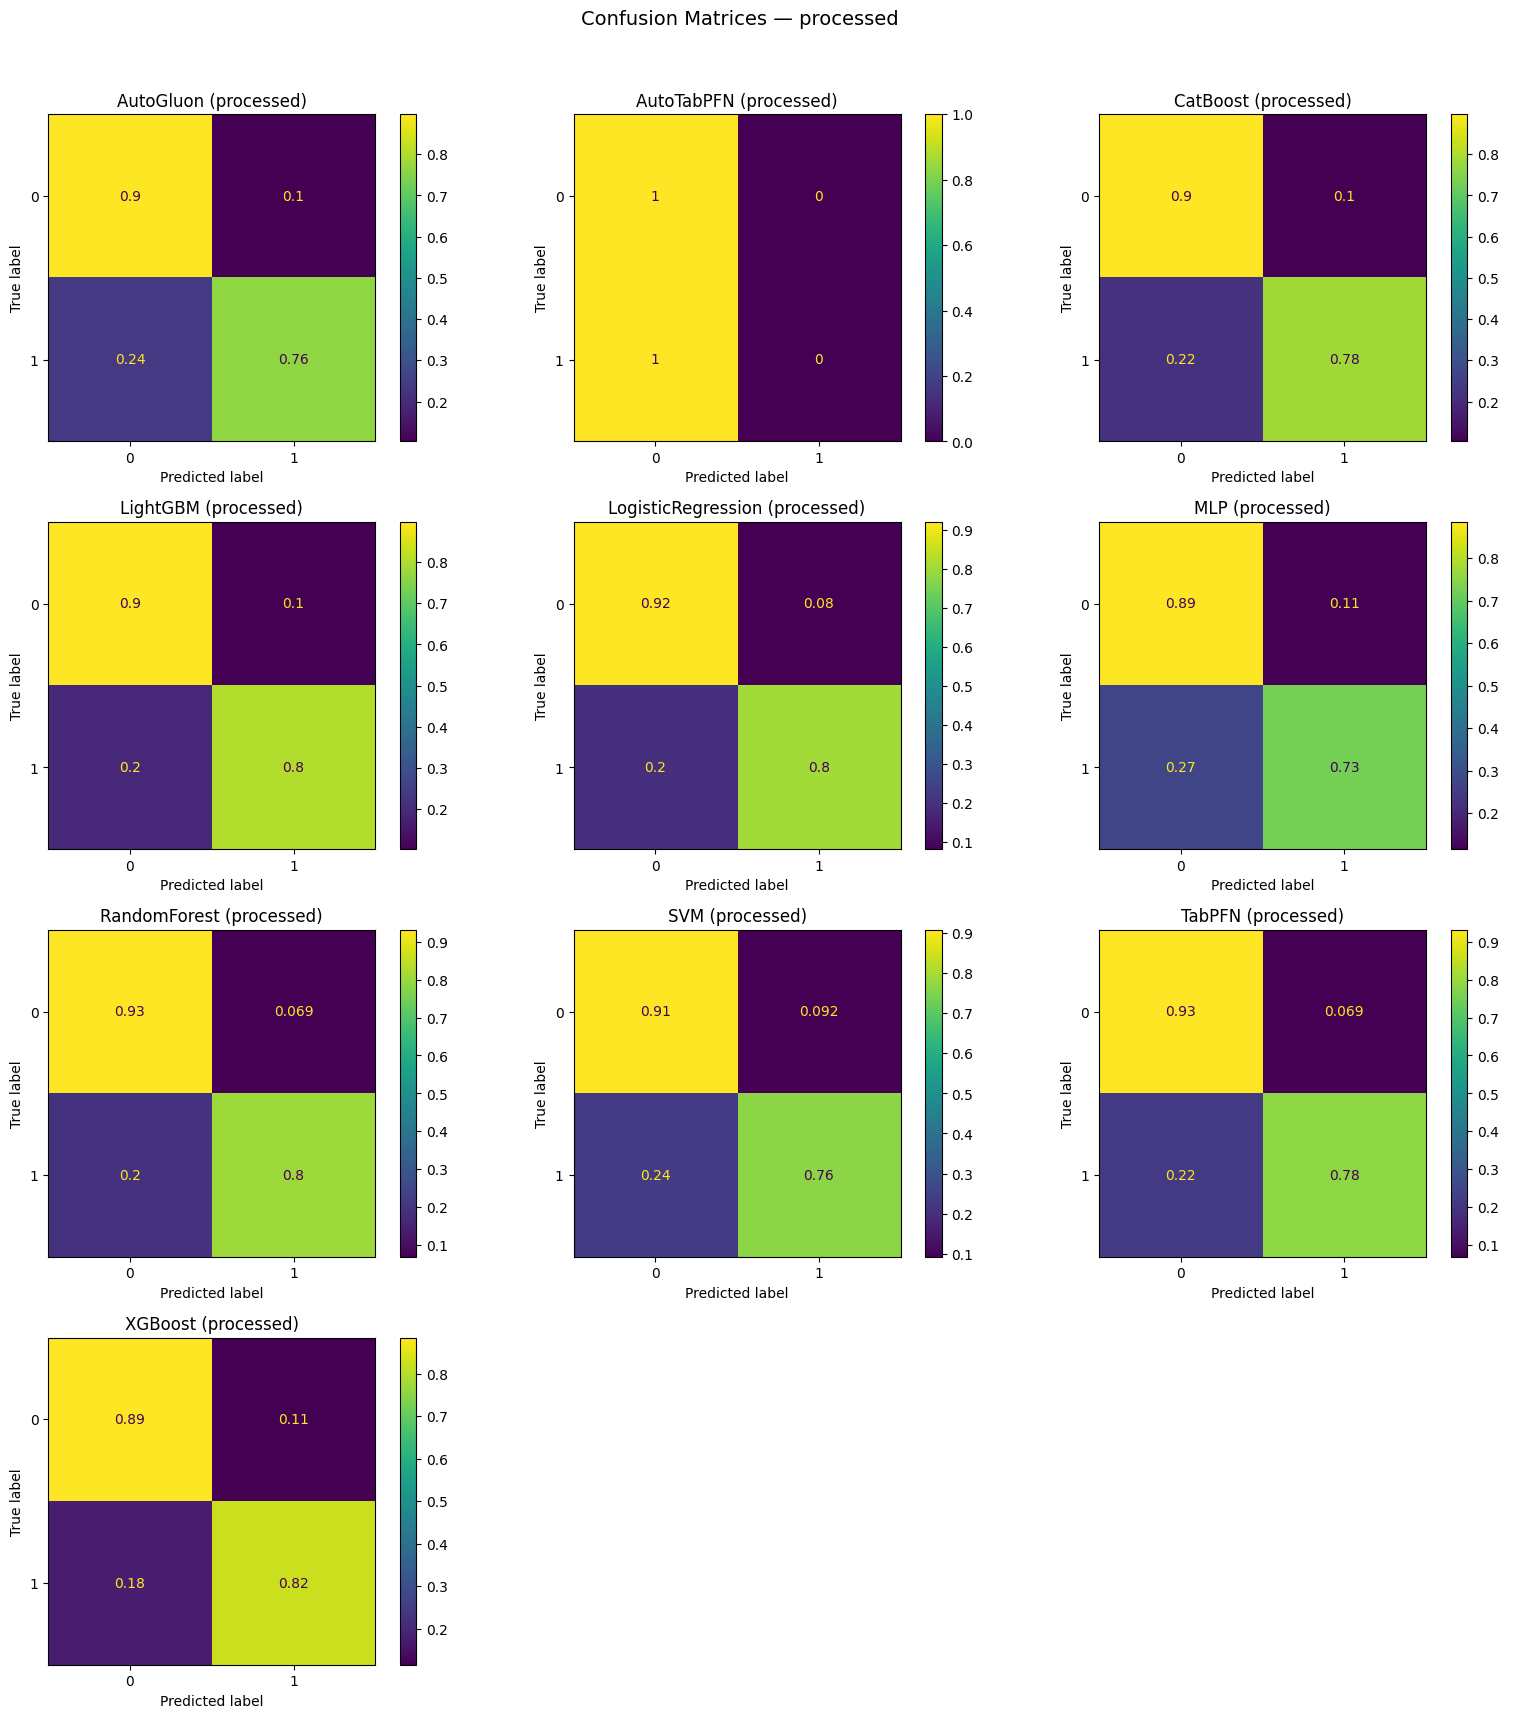

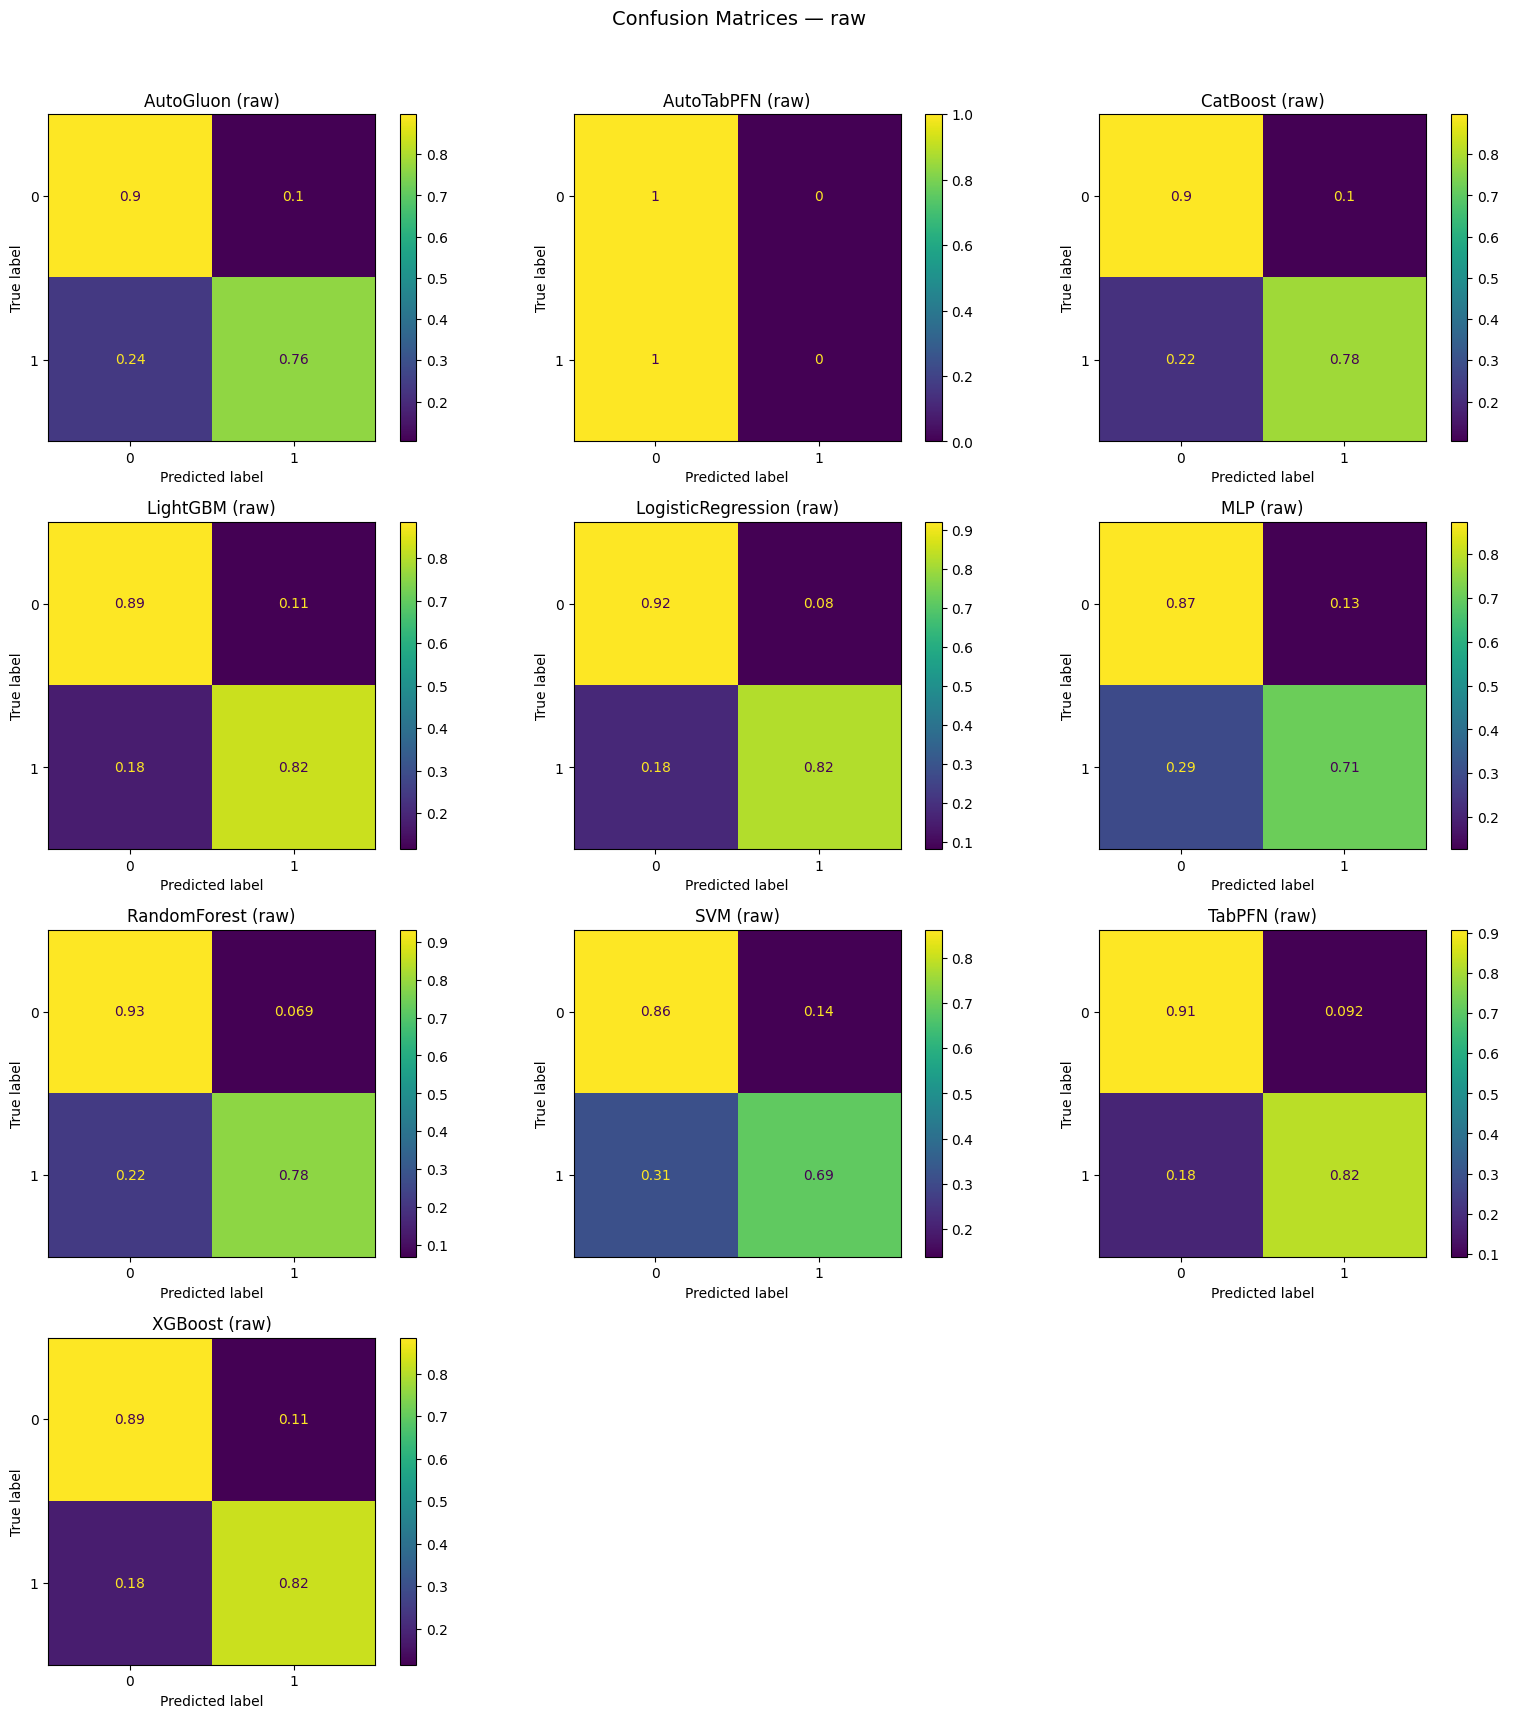

In [20]:
# Confusion Matrices — runs standalone and shows immediately

import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from sklearn.metrics import ConfusionMatrixDisplay
warnings.filterwarnings("ignore")

def _ensure_datasets_local():
    # Use existing `datasets` if present; else build from split vars
    if "datasets" in globals():
        return datasets
    d = {}
    if all(v in globals() for v in ["processed_X_train","processed_X_test","processed_y_train","processed_y_test"]):
        d["processed"] = (processed_X_train, processed_X_test, processed_y_train, processed_y_test)
    if all(v in globals() for v in ["raw_X_train","raw_X_test","raw_y_train","raw_y_test"]):
        d["raw"] = (raw_X_train, raw_X_test, raw_y_train, raw_y_test)
    if not d:
        raise RuntimeError("No datasets found. Define `datasets` or the processed/raw split variables.")
    return d

def _to_1d(a):
    if hasattr(a, "values"): a = a.values
    return np.asarray(a).ravel()

def _make_grid(n, ncols=3, base_h=4.2, width=16):
    nrows = max(1, int(np.ceil(n / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, max(base_h*nrows, 3.5)))
    return fig, (axes.ravel() if hasattr(axes, "ravel") else np.array([axes]))

ds_local = _ensure_datasets_local()
fitted = globals().get("fitted_models", {})

for ds_name in [k for k in ["processed","raw"] if k in ds_local]:
    X_tr, X_te, y_tr, y_te = ds_local[ds_name]
    y_true = _to_1d(y_te)
    keys = sorted([k for k in fitted if k[1] == ds_name], key=lambda x: x[0])

    if not keys:
        print(f"[Confusion] No models found for dataset='{ds_name}'")
        continue

    fig, axes = _make_grid(len(keys), ncols=3, base_h=4.2)
    for ax, (name, _) in zip(axes, keys):
        est = fitted[(name, ds_name)]
        y_pred = _to_1d(est.predict(X_te))
        ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize="true", ax=ax)
        ax.set_title(f"{name} ({ds_name})")
    for ax in axes[len(keys):]: ax.axis("off")
    fig.suptitle(f"Confusion Matrices — {ds_name}", y=1.02, fontsize=14)
    plt.tight_layout(); plt.show()

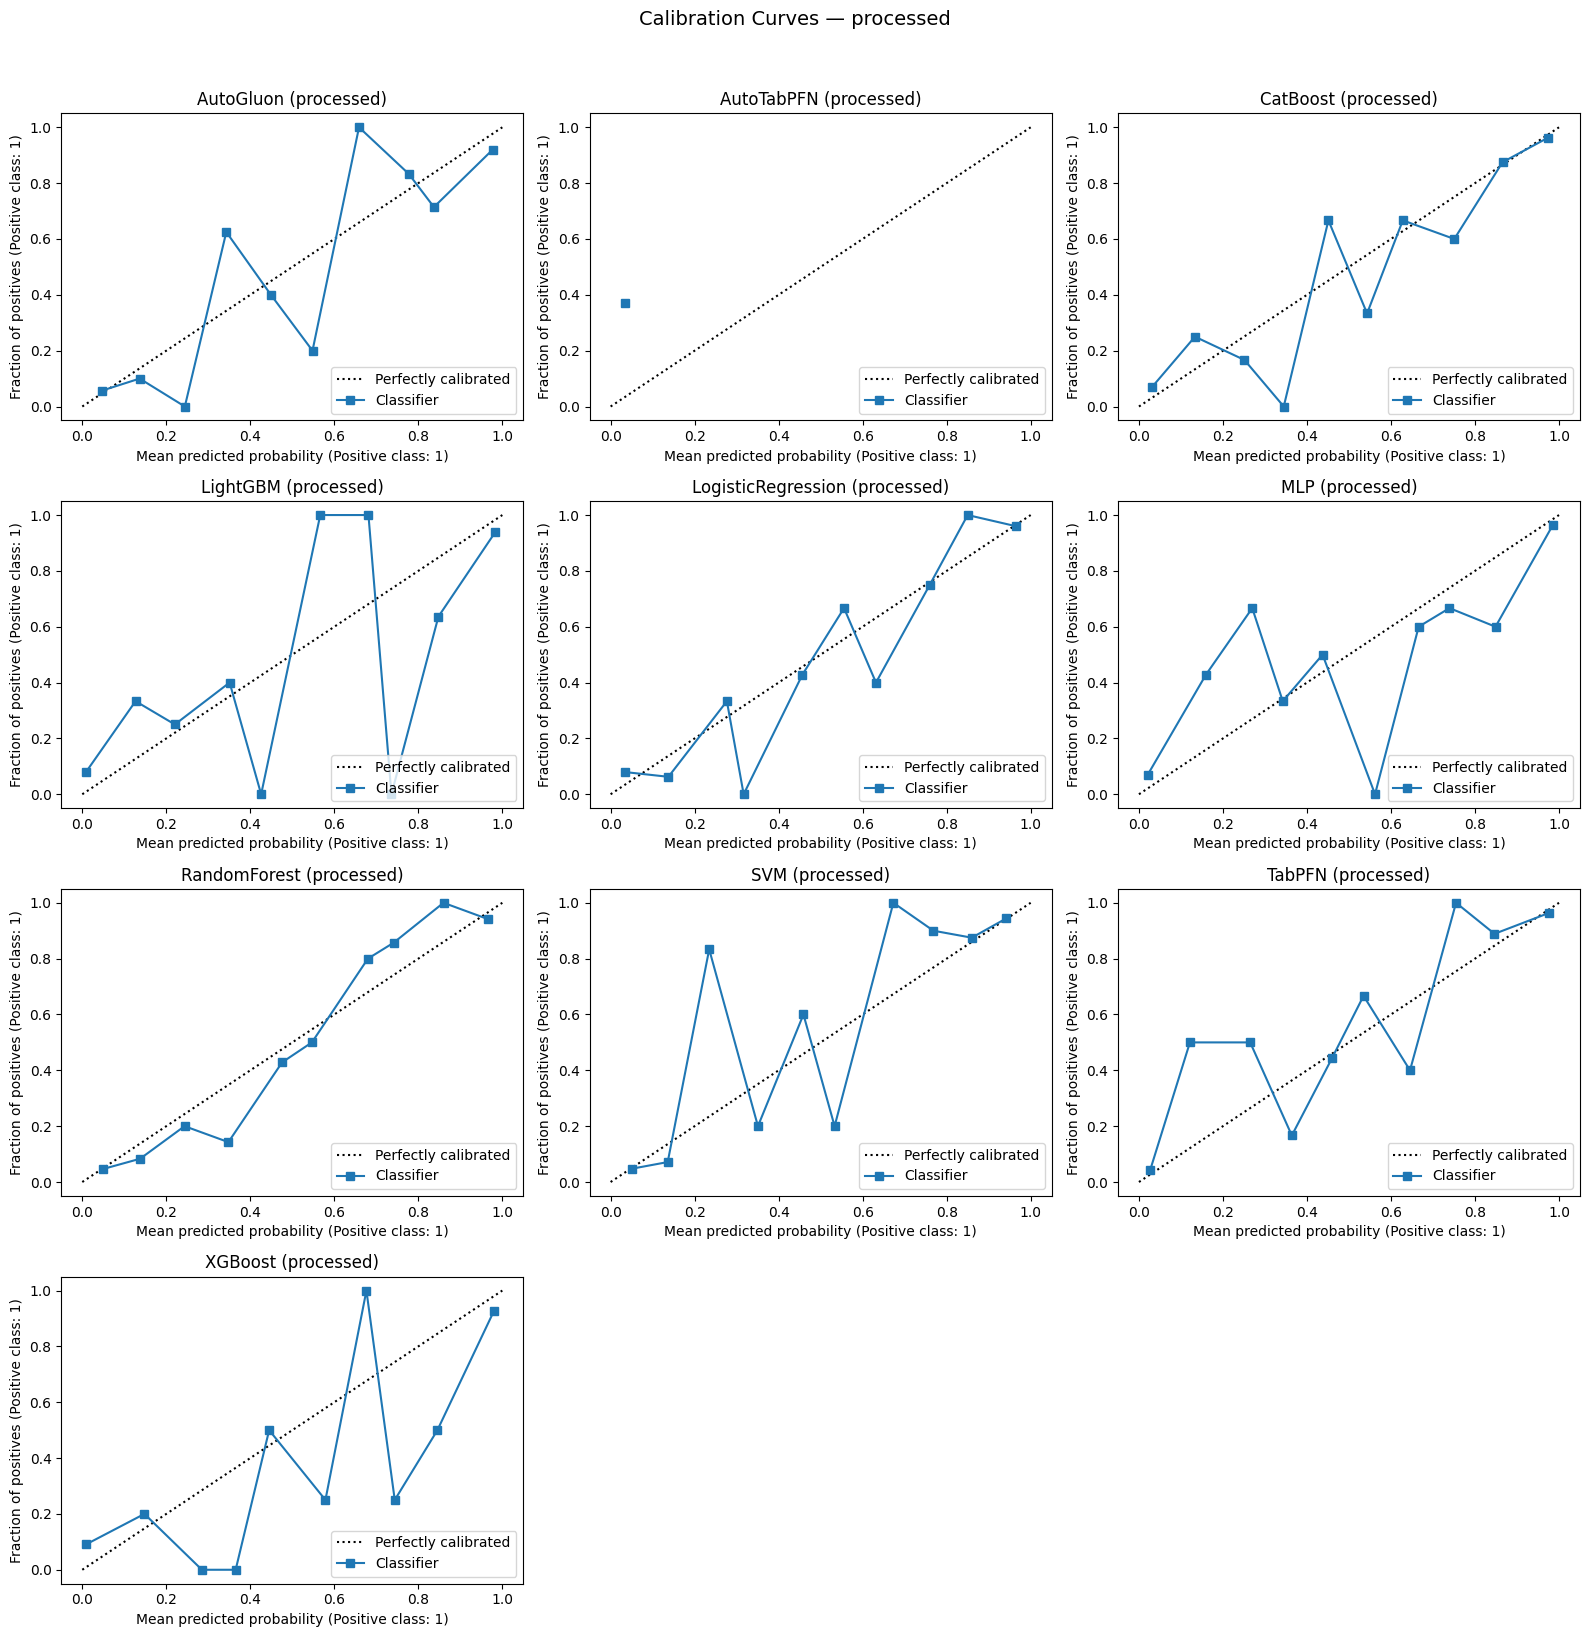

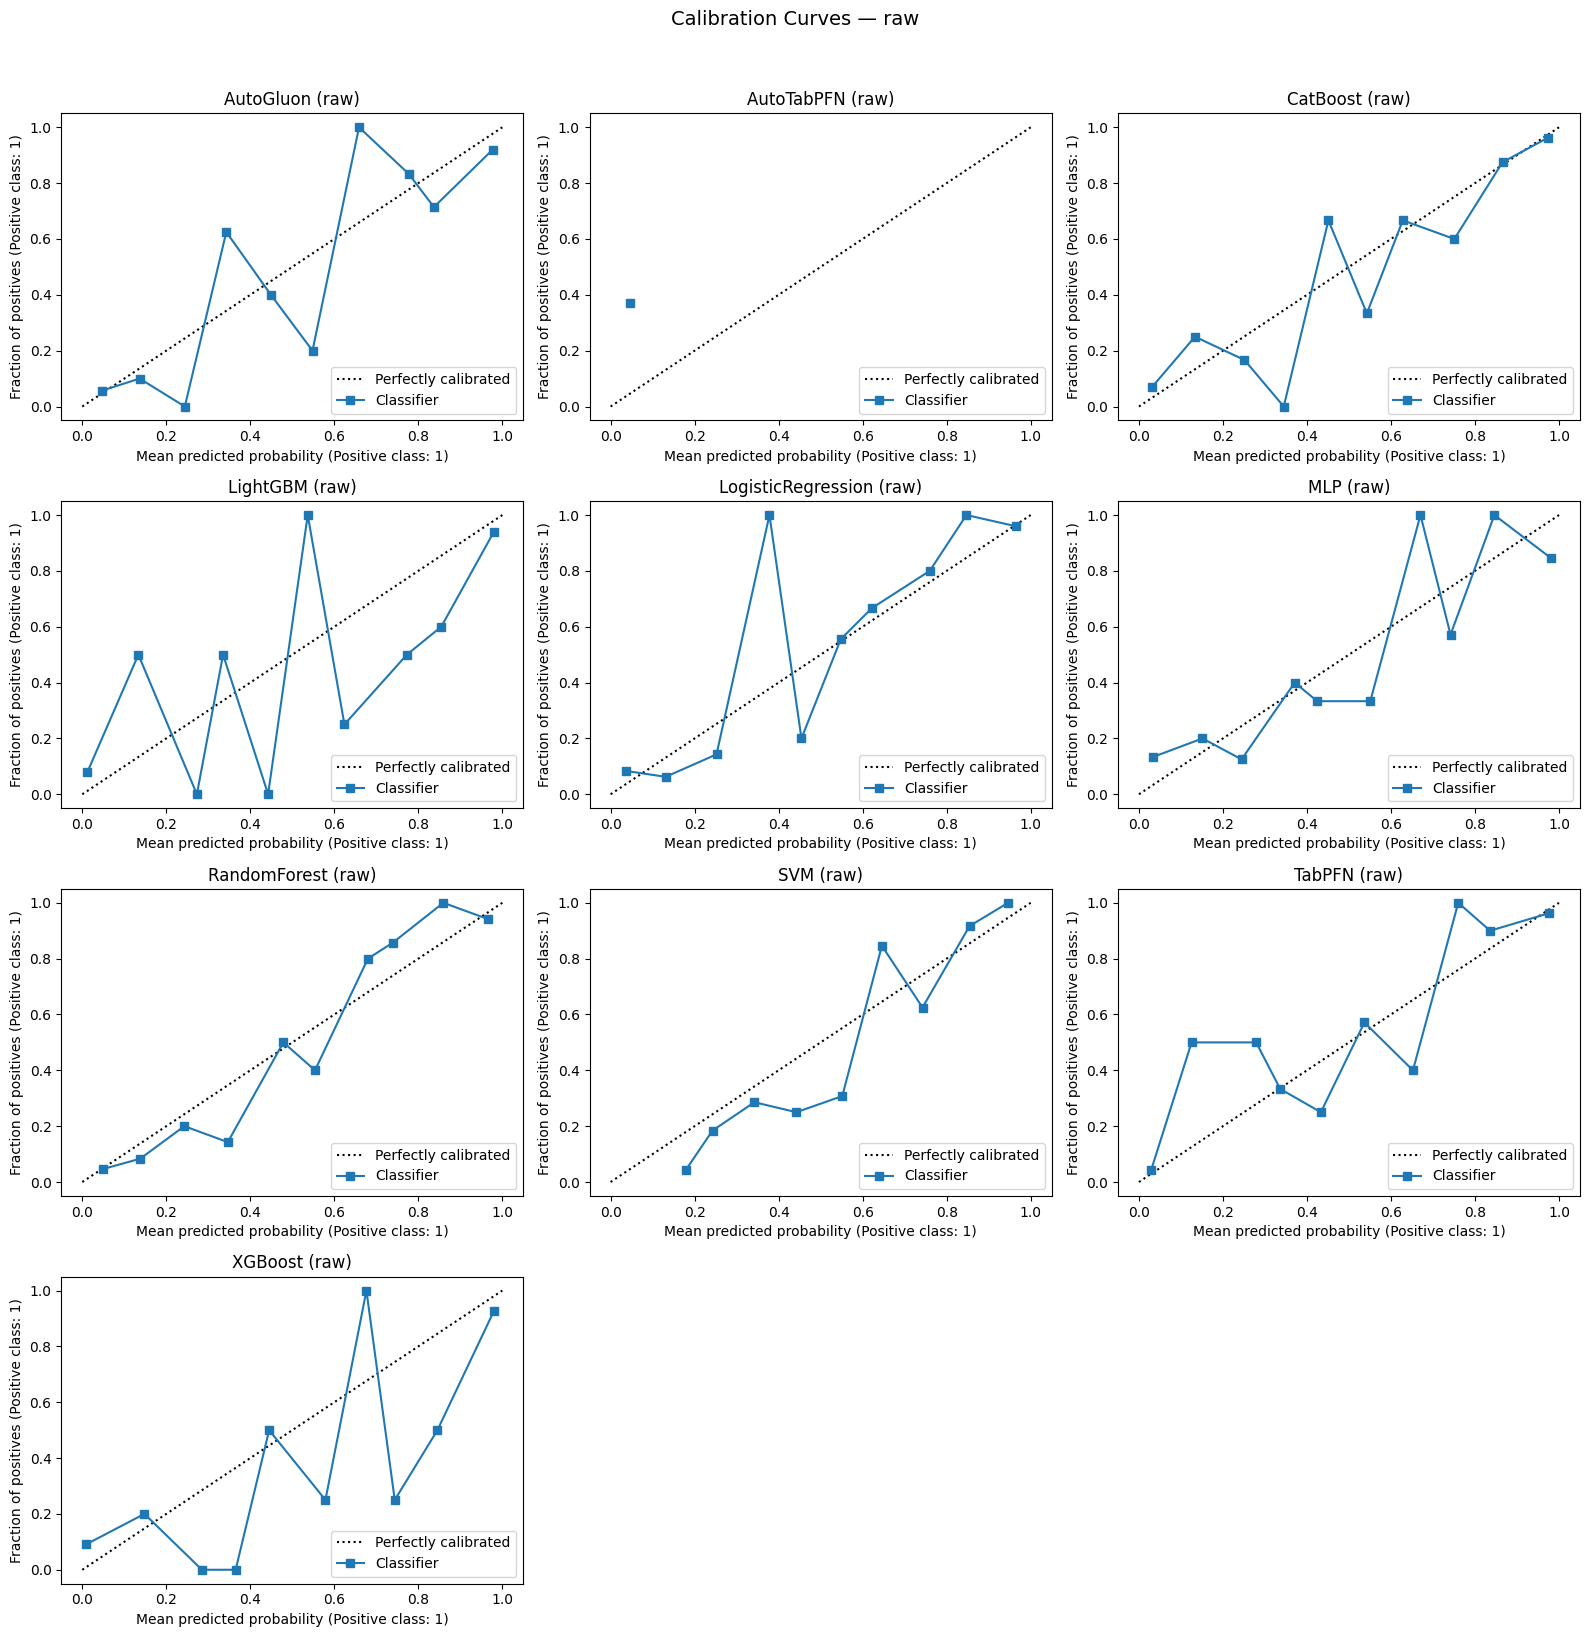

In [21]:
# Calibration Curves — runs standalone and shows immediately (binary only; skips others)

import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from sklearn.calibration import CalibrationDisplay
warnings.filterwarnings("ignore")

def _ensure_datasets_local():
    if "datasets" in globals():
        return datasets
    d = {}
    if all(v in globals() for v in ["processed_X_train","processed_X_test","processed_y_train","processed_y_test"]):
        d["processed"] = (processed_X_train, processed_X_test, processed_y_train, processed_y_test)
    if all(v in globals() for v in ["raw_X_train","raw_X_test","raw_y_train","raw_y_test"]):
        d["raw"] = (raw_X_train, raw_X_test, raw_y_train, raw_y_test)
    if not d:
        raise RuntimeError("No datasets found.")
    return d

def _to_1d(a):
    if hasattr(a, "values"): a = a.values
    return np.asarray(a).ravel()

def _prob_pos(est, X):
    try:
        proba = est.predict_proba(X)
    except Exception:
        return None
    if isinstance(proba, pd.DataFrame):
        return _to_1d(proba[1]) if 1 in proba.columns else _to_1d(proba.iloc[:, -1])
    if isinstance(proba, pd.Series):
        return _to_1d(proba)
    proba = np.asarray(proba)
    if proba.ndim == 2 and proba.shape[1] >= 2: return _to_1d(proba[:, -1])
    if proba.ndim == 1: return _to_1d(proba)
    return None

def _make_grid(n, ncols=3, base_h=4.0, width=16):
    nrows = max(1, int(np.ceil(n / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, max(base_h*nrows, 3.5)))
    return fig, (axes.ravel() if hasattr(axes, "ravel") else np.array([axes]))

ds_local = _ensure_datasets_local()
fitted = globals().get("fitted_models", {})

for ds_name in [k for k in ["processed","raw"] if k in ds_local]:
    X_tr, X_te, y_tr, y_te = ds_local[ds_name]
    y_true = _to_1d(y_te)
    is_binary = (np.unique(y_true).size == 2)
    keys = sorted([k for k in fitted if k[1] == ds_name], key=lambda x: x[0])

    if not keys:
        print(f"[Calibration] No models found for dataset='{ds_name}'")
        continue

    fig, axes = _make_grid(len(keys), ncols=3, base_h=4.0)
    for ax, (name, _) in zip(axes, keys):
        est = fitted[(name, ds_name)]
        y_prob = _prob_pos(est, X_te)
        if (not is_binary) or (y_prob is None):
            ax.text(0.5, 0.5, "Skipped\n(multiclass or no proba)", ha="center", va="center")
            ax.set_axis_off()
        else:
            CalibrationDisplay.from_predictions(y_true, y_prob, n_bins=10, ax=ax)
            ax.set_title(f"{name} ({ds_name})")
    for ax in axes[len(keys):]: ax.axis("off")
    title = f"Calibration Curves — {ds_name}" + ("" if is_binary else " (binary only)")
    fig.suptitle(title, y=1.02, fontsize=14)
    plt.tight_layout(); plt.show()

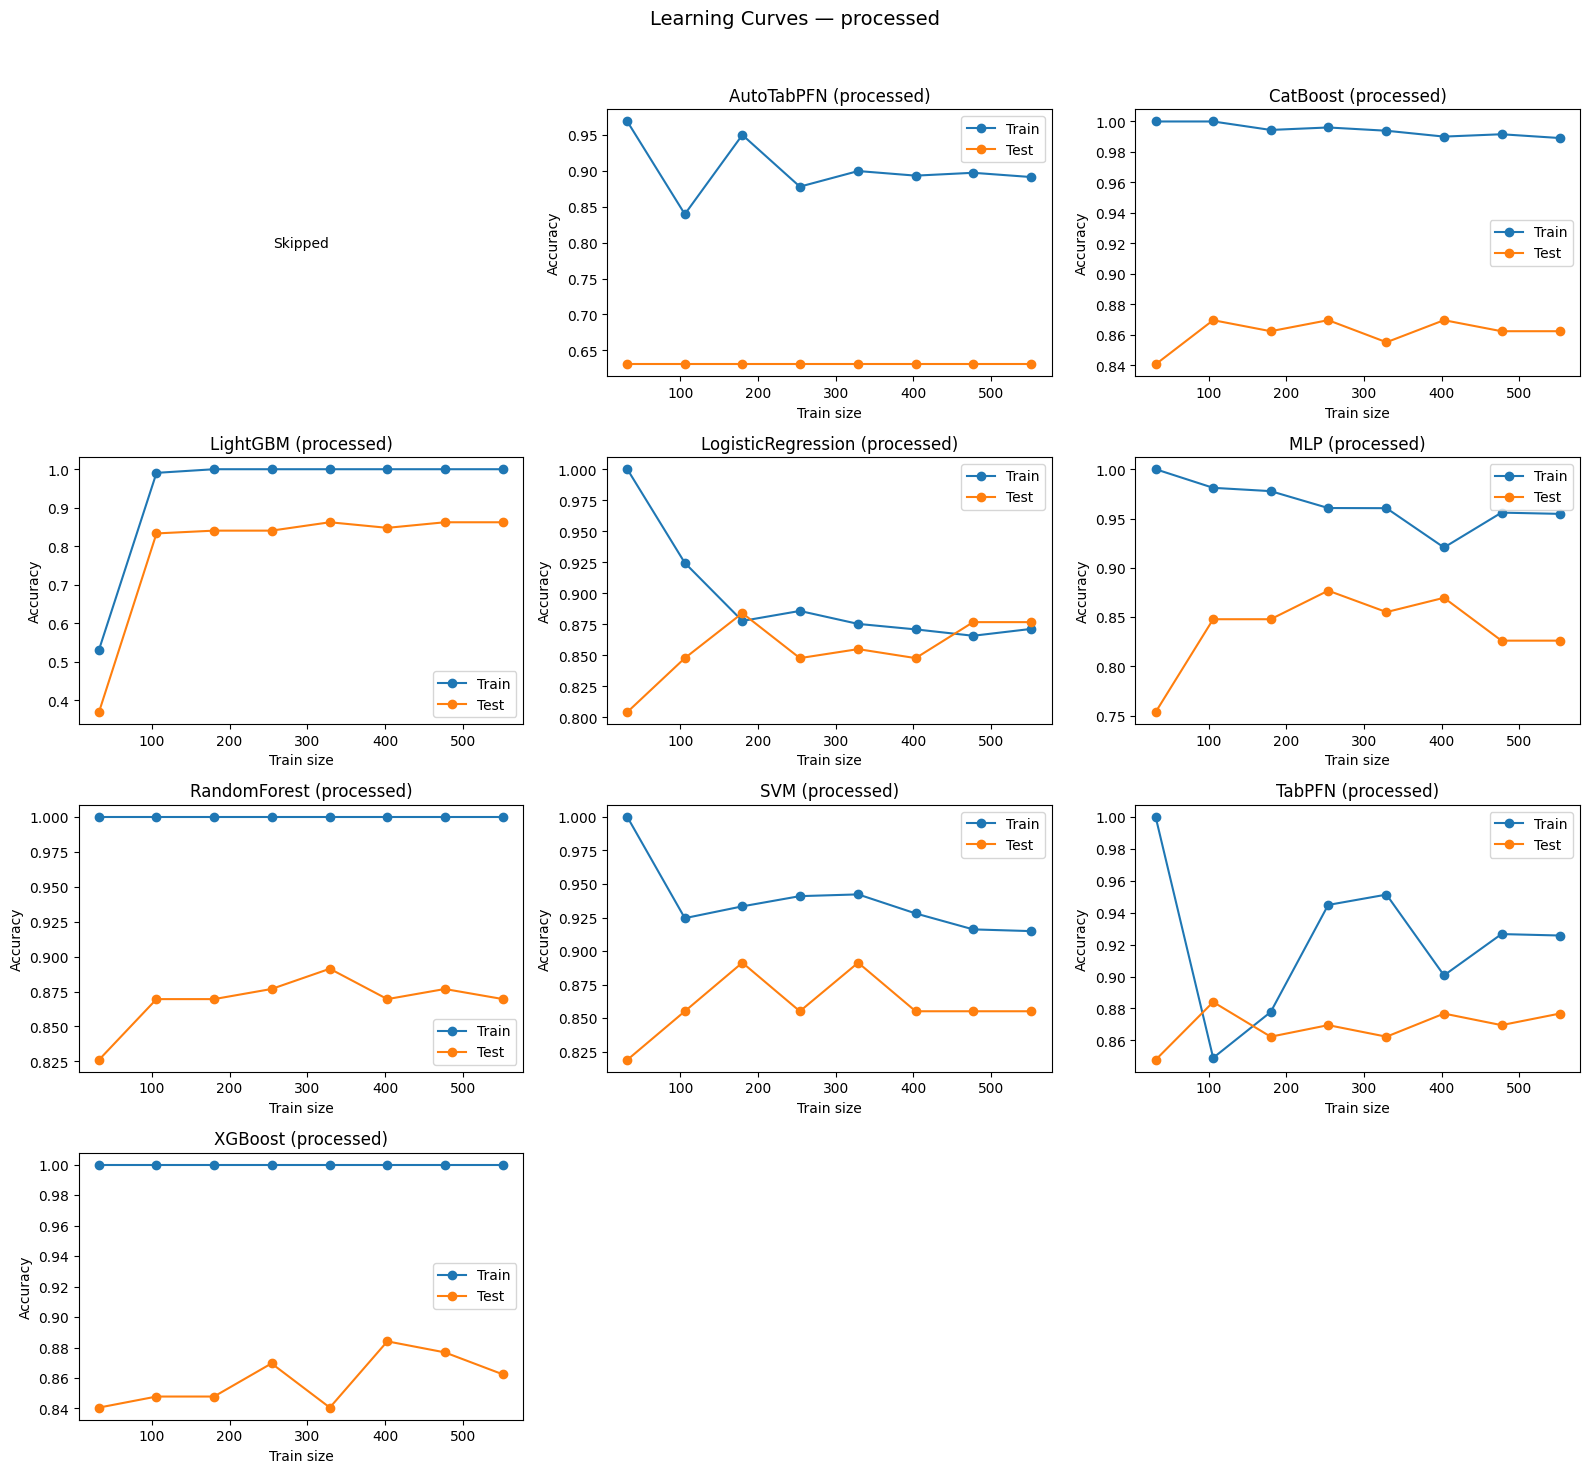

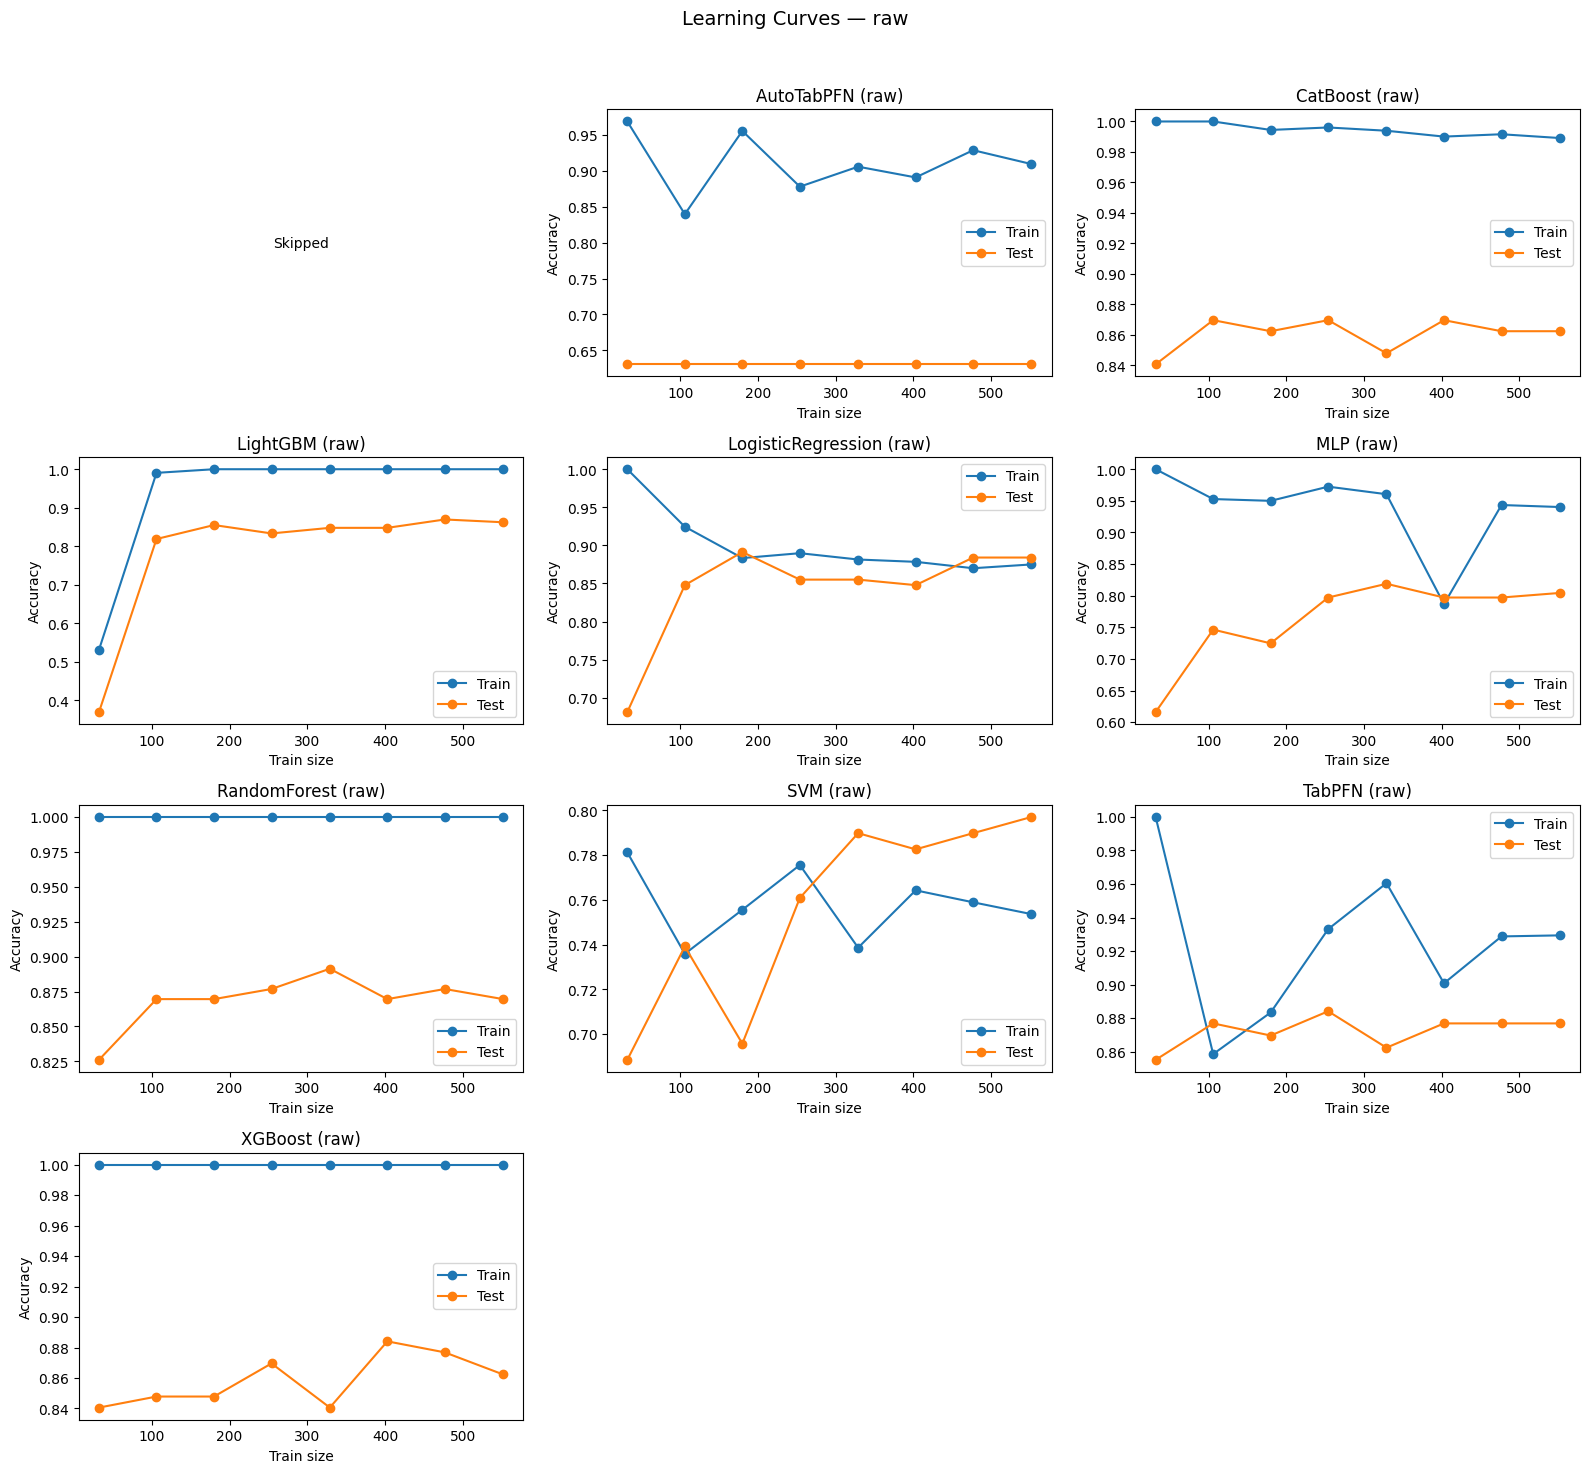

In [22]:
# Learning Curves — runs standalone and shows immediately (re-fits lightweight models)

import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from sklearn.metrics import accuracy_score
warnings.filterwarnings("ignore")

def _ensure_datasets_local():
    if "datasets" in globals():
        return datasets
    d = {}
    if all(v in globals() for v in ["processed_X_train","processed_X_test","processed_y_train","processed_y_test"]):
        d["processed"] = (processed_X_train, processed_X_test, processed_y_train, processed_y_test)
    if all(v in globals() for v in ["raw_X_train","raw_X_test","raw_y_train","raw_y_test"]):
        d["raw"] = (raw_X_train, raw_X_test, raw_y_train, raw_y_test)
    if not d:
        raise RuntimeError("No datasets found.")
    return d

def _to_1d(a):
    if hasattr(a, "values"): a = a.values
    return np.asarray(a).ravel()

def _ctor_for(name):
    # Base sklearn models
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.svm import SVC
    from sklearn.neural_network import MLPClassifier
    from sklearn.linear_model import LogisticRegression
    mapping = {
        "RandomForest":       lambda: RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1),
        "SVM":                lambda: SVC(probability=True, random_state=42),
        "MLP":                lambda: MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42),
        "LogisticRegression": lambda: LogisticRegression(max_iter=1000, solver="lbfgs"),
    }
    # Optional extras
    try:
        import xgboost as xgb
        mapping["XGBoost"] = lambda: xgb.XGBClassifier(eval_metric="logloss", random_state=42, tree_method="hist")
    except Exception: pass
    try:
        import lightgbm as lgb
        mapping["LightGBM"] = lambda: lgb.LGBMClassifier(random_state=42)
    except Exception: pass
    try:
        import catboost as cb
        mapping["CatBoost"] = lambda: cb.CatBoostClassifier(verbose=False, random_seed=42)
    except Exception: pass
    try:
        from tabpfn import TabPFNClassifier
        mapping["TabPFN"] = lambda: TabPFNClassifier(random_state=42)
    except Exception: pass
    try:
        from tabpfn_extensions.post_hoc_ensembles.sklearn_interface import AutoTabPFNClassifier
        mapping["AutoTabPFN"] = lambda: AutoTabPFNClassifier(random_state=42)
    except Exception: pass
    # AutoGluon intentionally skipped (non-sklearn API)
    return mapping.get(name)

def _make_grid(n, ncols=3, base_h=3.6, width=16):
    nrows = max(1, int(np.ceil(n / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, max(base_h*nrows, 3.5)))
    return fig, (axes.ravel() if hasattr(axes, "ravel") else np.array([axes]))

ds_local = _ensure_datasets_local()
fitted = globals().get("fitted_models", {})

for ds_name in [k for k in ["processed","raw"] if k in ds_local]:
    X_tr, X_te, y_tr, y_te = ds_local[ds_name]
    X_tr_np = getattr(X_tr, "values", X_tr)
    y_tr_np = _to_1d(y_tr)

    keys = sorted([k for k in fitted if k[1] == ds_name], key=lambda x: x[0])
    if not keys:
        print(f"[Learning Curves] No models found for dataset='{ds_name}'")
        continue

    steps, min_size, random_state = 8, 32, 42
    sizes = np.unique(np.clip(np.linspace(min_size, len(X_tr_np), steps, dtype=int), min_size, len(X_tr_np)))

    fig, axes = _make_grid(len(keys), ncols=3, base_h=3.6)
    rng = np.random.RandomState(random_state)

    for ax, (name, _) in zip(axes, keys):
        ctor = _ctor_for(name)
        if ctor is None or name == "AutoGluon":
            ax.text(0.5, 0.5, "Skipped", ha="center", va="center"); ax.set_axis_off(); continue
        train_scores, test_scores = [], []
        for n in sizes:
            idx = rng.permutation(len(X_tr_np))[:n]
            est = ctor()
            Xn = X_tr_np[idx] if hasattr(X_tr_np, "__getitem__") else X_tr.iloc[idx]
            yn = y_tr_np[idx]
            try:
                est.fit(Xn, yn)
                tr_pred = _to_1d(est.predict(Xn))
                te_pred = _to_1d(est.predict(X_te))
                train_scores.append(accuracy_score(yn, tr_pred))
                test_scores.append(accuracy_score(_to_1d(y_te), te_pred))
            except Exception:
                train_scores.append(np.nan); test_scores.append(np.nan)
        ax.plot(sizes, train_scores, "o-", label="Train")
        ax.plot(sizes, test_scores, "o-", label="Test")
        ax.set_title(f"{name} ({ds_name})"); ax.set_xlabel("Train size"); ax.set_ylabel("Accuracy"); ax.legend()
    for ax in axes[len(keys):]: ax.axis("off")
    plt.suptitle(f"Learning Curves — {ds_name}", y=1.02, fontsize=14)
    plt.tight_layout(); plt.show()

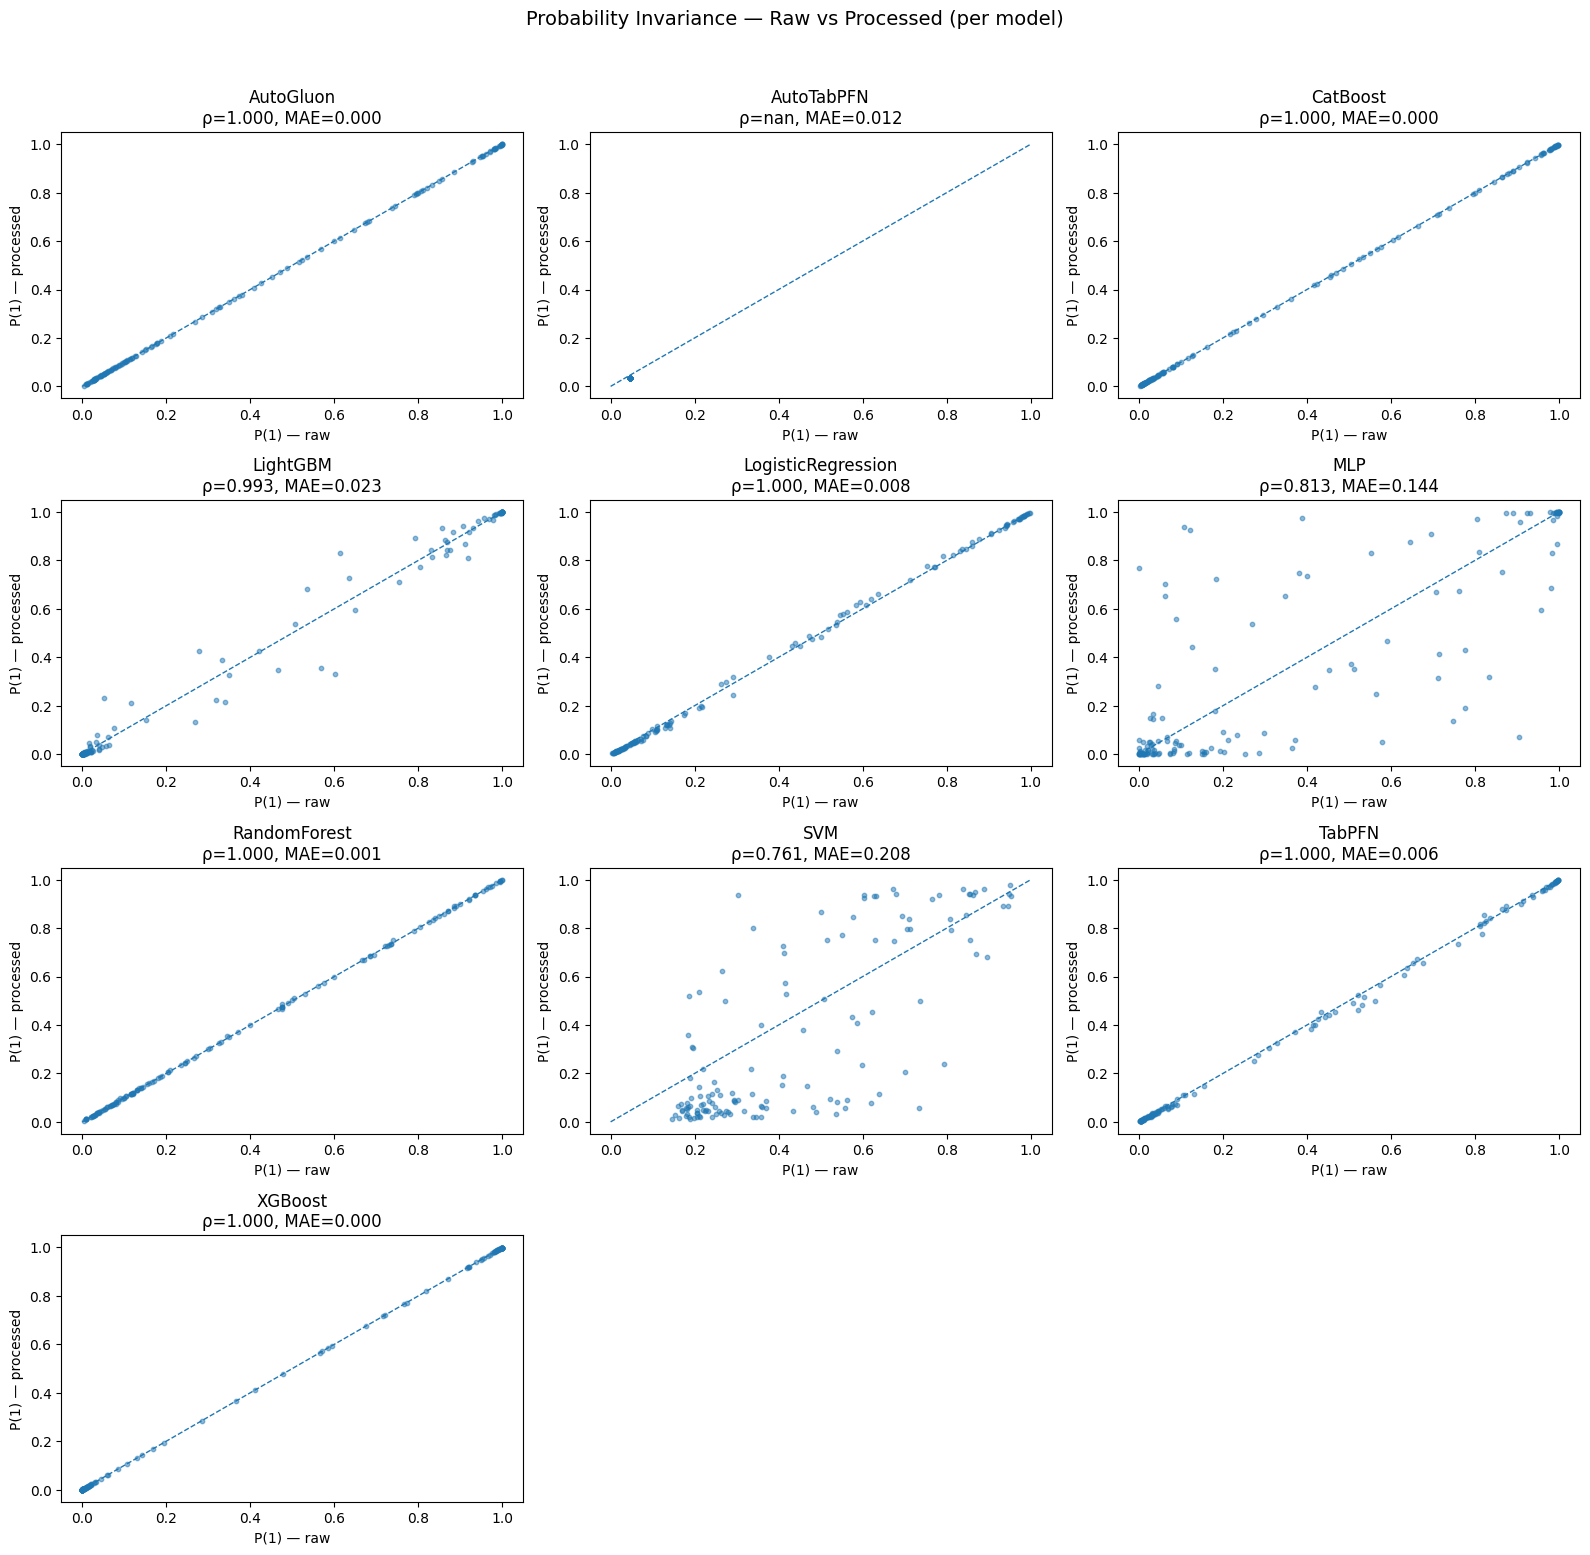

In [23]:
# Probability Invariance — runs standalone and shows immediately
# Compares P(class=1) from each model on raw vs processed test sets.

import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")

def _ensure_datasets_local():
    if "datasets" in globals():
        return datasets
    d = {}
    if all(v in globals() for v in ["processed_X_train","processed_X_test","processed_y_train","processed_y_test"]):
        d["processed"] = (processed_X_train, processed_X_test, processed_y_train, processed_y_test)
    if all(v in globals() for v in ["raw_X_train","raw_X_test","raw_y_train","raw_y_test"]):
        d["raw"] = (raw_X_train, raw_X_test, raw_y_train, raw_y_test)
    if not d:
        raise RuntimeError("Need both 'raw' and 'processed' to run probability invariance.")
    return d

def _to_1d(a):
    if hasattr(a, "values"): a = a.values
    return np.asarray(a).ravel()

def _prob_pos(est, X):
    try:
        proba = est.predict_proba(X)
    except Exception:
        return None
    if isinstance(proba, pd.DataFrame):
        return _to_1d(proba[1]) if 1 in proba.columns else _to_1d(proba.iloc[:, -1])
    if isinstance(proba, pd.Series):
        return _to_1d(proba)
    proba = np.asarray(proba)
    if proba.ndim == 2 and proba.shape[1] >= 2: return _to_1d(proba[:, -1])
    if proba.ndim == 1: return _to_1d(proba)
    return None

def _make_grid(n, ncols=3, base_h=3.8, width=16):
    nrows = max(1, int(np.ceil(n / ncols)))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width, max(base_h*nrows, 3.5)))
    return fig, (axes.ravel() if hasattr(axes, "ravel") else np.array([axes]))

ds_local = _ensure_datasets_local()
if not ("raw" in ds_local and "processed" in ds_local):
    raise RuntimeError("Need both 'raw' and 'processed' in datasets for probability invariance.")

_, X_te_p, _, _ = ds_local["processed"]
_, X_te_r, _, _ = ds_local["raw"]
fitted = globals().get("fitted_models", {})

names = sorted(set(n for (n,d) in fitted if d == "raw") & set(n for (n,d) in fitted if d == "processed"))
if not names:
    print("No overlapping models across raw and processed.")
else:
    fig, axes = _make_grid(len(names), ncols=3, base_h=3.8)
    for ax, name in zip(axes, names):
        est_p = fitted.get((name, "processed"))
        est_r = fitted.get((name, "raw"))
        if est_p is None or est_r is None:
            ax.text(0.5, 0.5, "Missing model", ha="center", va="center"); ax.set_axis_off(); continue
        p_p = _prob_pos(est_p, X_te_p)
        p_r = _prob_pos(est_r, X_te_r)
        if p_p is None or p_r is None:
            ax.text(0.5, 0.5, "No probabilities", ha="center", va="center"); ax.set_axis_off(); continue

        m = min(len(p_p), len(p_r))
        p_p, p_r = np.asarray(p_p)[:m], np.asarray(p_r)[:m]
        ax.scatter(p_r, p_p, s=10, alpha=0.5)
        ax.plot([0,1], [0,1], "--", lw=1)
        with np.errstate(invalid="ignore"):
            corr = np.corrcoef(p_r, p_p)[0,1]
            mae  = float(np.nanmean(np.abs(p_p - p_r)))
        ax.set_title(f"{name}\nρ={corr:.3f}, MAE={mae:.3f}")
        ax.set_xlabel("P(1) — raw"); ax.set_ylabel("P(1) — processed")
    for ax in axes[len(names):]: ax.axis("off")
    plt.suptitle("Probability Invariance — Raw vs Processed (per model)", y=1.02, fontsize=14)
    plt.tight_layout(); plt.show()